In [12]:
from pathlib import Path
import re

import mne
import numpy as np


def parse_txt_channel(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns:
        times: int64 ticks
        eeg:   float64 values
    """
    with path.open("r") as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        raise ValueError(f"{path}: empty file")

    def parse_row(line: str) -> tuple[int, float]:
        columns = line.split()

        if len(columns) != 2:
            raise ValueError(f"Expected 2 columns, got {columns}")

        time_str, eeg_str = columns

        time = int(time_str.replace(".", ""))
        eeg_value = float(eeg_str)

        return time, eeg_value

    # First row may or may not be a header
    try:
        first = parse_row(lines[0])
        data_lines = lines
    except ValueError:
        data_lines = lines[1:]

    times = []
    eeg_values = []

    for line_number, line in enumerate(data_lines, start=1):
        try:
            time, eeg_value = parse_row(line)
        except ValueError as e:
            raise ValueError(f"{path}:{line_number}: invalid data row: {line}") from e

        times.append(time)
        eeg_values.append(eeg_value)

    times = np.asarray(times, dtype=np.int64)
    eeg = np.asarray(eeg_values, dtype=float)

    if len(times) < 2:
        raise ValueError(f"{path}: need at least 2 samples")

    return times, eeg


def load_samples(root: str | Path) -> list[Sample]:
    """
    Recursively find all *_2Hz.txt files.

    Files belonging to the same participant + line are combined
    as EEG channels of ONE Sample.

    Example:

        O1_v1_p10_2Hz.txt
        O2_v1_p10_2Hz.txt
        F3_v1_p10_2Hz.txt
        F4_v1_p10_2Hz.txt

    becomes one Sample:

        participant = 10
        line = 1
        data.ch_names = ["O1", "O2", "F3", "F4"]
    """

    FILE_RE = re.compile(
        r"(?P<channel>[^_]+)_v(?P<line>\d+)_p(?P<participant>\d+)_2Hz\.txt$"
    )

    root = Path(root)

    # (participant, line) -> [(channel_name, path), ...]
    groups: dict[tuple[int, int], list[tuple[str, Path]]] = {}

    for path in sorted(root.rglob("*_2Hz.txt")):
        match = FILE_RE.match(path.name)

        if match is None:
            print(f"Skipping unrecognized filename: {path}")
            continue

        channel_name = match.group("channel")
        line = int(match.group("line"))
        participant = int(match.group("participant"))

        key = (participant, line)

        groups.setdefault(key, []).append((channel_name, path))

    samples: list[Sample] = []

    for (participant, line), channel_files in sorted(groups.items()):
        try:
            channel_names = []
            channel_data = []

            reference_times = None

            for channel_name, path in sorted(channel_files):
                times, eeg = parse_txt_channel(path)

                # First channel establishes the timestamps
                if reference_times is None:
                    reference_times = times

                else:
                    # All channels in the same experience should align
                    if len(times) != len(reference_times):
                        raise ValueError(
                            f"Participant {participant}, line {line}: "
                            f"channel {channel_name} has {len(times)} samples, "
                            f"expected {len(reference_times)}"
                        )

                    if not np.array_equal(times, reference_times):
                        raise ValueError(
                            f"Participant {participant}, line {line}: "
                            f"timestamps for channel {channel_name} "
                            f"do not match the other channels"
                        )

                channel_names.append(channel_name)
                channel_data.append(eeg)

            # ---------------------------------------------
            # Infer sampling frequency
            # ---------------------------------------------

            # 25.078.125 -> 25,078,125 -> 2.5078125 sec
            time_s = reference_times / 1e7

            dt_s = np.diff(time_s)

            if np.any(dt_s <= 0):
                raise ValueError(
                    f"Participant {participant}, line {line}: "
                    "timestamps are not strictly increasing"
                )

            sfreq = 1.0 / np.median(dt_s)

            # ---------------------------------------------
            # Build multi-channel MNE object
            # ---------------------------------------------

            # shape:
            # (n_channels, n_times)
            data = np.vstack(channel_data)

            info = mne.create_info(
                ch_names=channel_names,
                sfreq=sfreq,
                ch_types=["eeg"] * len(channel_names),
            )

            raw = mne.io.RawArray(
                data,
                info,
                verbose=False,
            )

            # ---------------------------------------------
            # Build ONE sample for this experience
            # ---------------------------------------------

            sample = Sample.from_auto_label(
                participant=participant,
                line=line,
                data=raw,
            )

            samples.append(sample)

        except Exception as e:
            print(f"Error loading participant={participant}, " f"line={line}: {e}")

    return samples

In [2]:
path = Path(r"~/Downloads/txt data filtered 2Hz")
path = path.expanduser()
path

PosixPath('/home/tu/Downloads/txt data filtered 2Hz')

In [13]:
samples = load_samples(path)
len(samples)

/tmp/ipykernel_1194854/1576094929.py:166: RuntimeWarning: Channel names are not unique, found duplicates for: {'O1'}. Applying running numbers for duplicates.
  info = mne.create_info(


Error loading participant=5, line=23: Participant 5, line 23: channel F7 has 750 samples, expected 910
Error loading participant=18, line=1: Participant 18, line 1: channel P8 has 693 samples, expected 643
Error loading participant=23, line=9: Participant 23, line 9: channel P3 has 490 samples, expected 582
Error loading participant=23, line=10: Participant 23, line 10: channel Fp2 has 648 samples, expected 910
Error loading participant=44, line=4: Participant 44, line 4: channel F3 has 786 samples, expected 777
Error loading participant=54, line=5: Participant 54, line 5: channel P3 has 786 samples, expected 586


694

In [15]:
import random

raw_eeg = random.choice(samples).data
raw_eeg

<RawArray | 18 x 586 (2.3 s), ~100 KiB, data loaded>

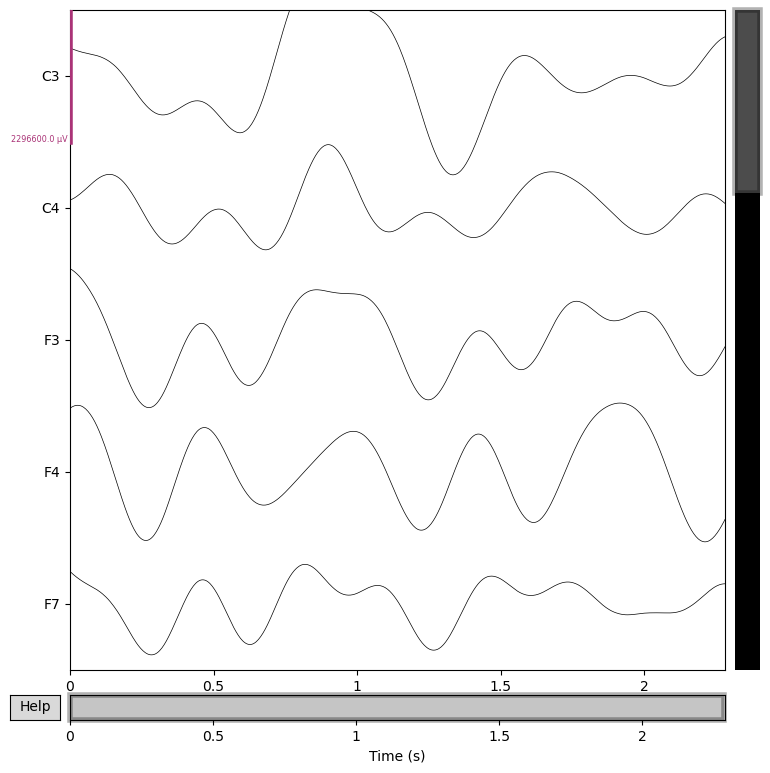

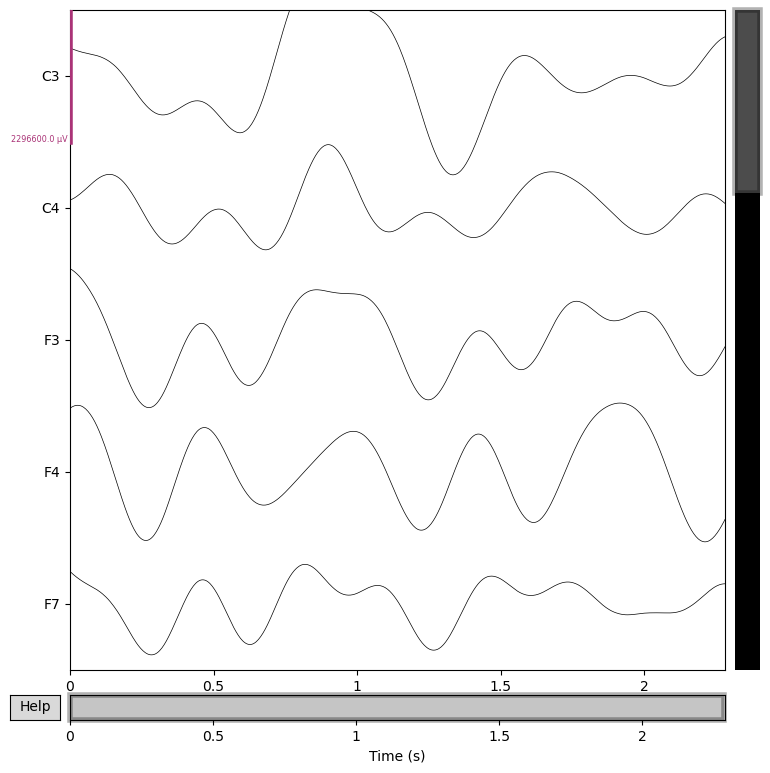

In [18]:
raw_eeg.plot(
    n_channels=5,
    scalings="auto",
)

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


/home/tu/micromamba/envs/nbm/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


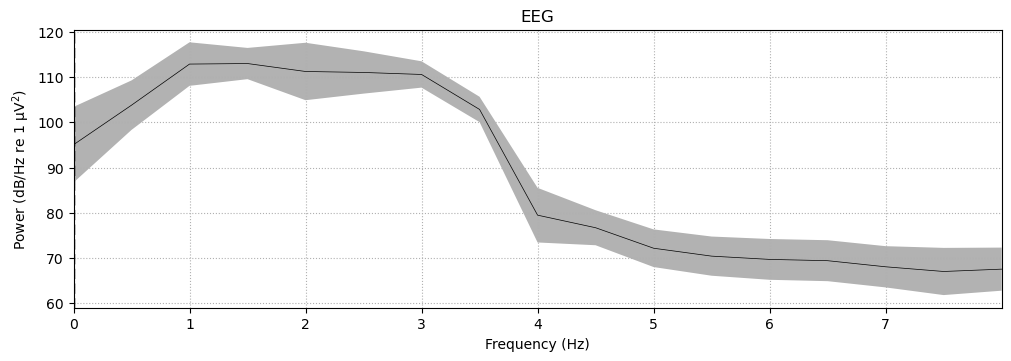

In [20]:
from matplotlib import pyplot as plt


spectrum = raw_eeg.compute_psd(
    method="welch",
    fmin=0,
    fmax=8,
    n_fft=512,
    n_overlap=256,
)

b = spectrum.plot(
    average=True,
    dB=True,
)

plt.show()